In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load TraiChoise Moderate 1% standart - we simulate the behavior of mainnet - not pure work load(tx/block))
ARRIVAL_SCALE = 0.1
arrivals = (train_df['transaction_count'] * ARRIVAL_SCALE).values

print(f"Mean Arrival Rate (λ): {arrivals.mean():.2f} tx/block")
print(f"P99 Arrival Burst: {np.quantile(arrivals, 0.99):.2f} tx/block")


Mean Arrival Rate (λ): 17.53 tx/block
P99 Arrival Burst: 46.60 tx/block


In [ ]:
def simulate_queue(arrivals, capacity):
    n = len(arrivals)
    queue = np.zeros(n)
    missed_tx = 0
    
    current_q = 0
    for t in range(n):
        # 1. New tx added to queue
        current_q += arrivals[t]
        
        # 2. excution (not over capacity)
        executed = min(current_q, capacity)
        current_q -= executed
        
        # 3. Store state
        queue[t] = current_q
        
    return queue

# Try in difference Capacity
capacities = [10, 50, 100, 200, 500, 1000]
results = {}

for cap in capacities:
    q_trace = simulate_queue(arrivals, cap)
    results[cap] = {
        "Mean Queue": q_trace.mean(),
        "Max Queue": q_trace.max(),
        "Is Stable": q_trace[-1] < q_trace.mean() * 2 # Check exposion in queue ? 
    }

print("=== QUEUE STABILITY RESULTS ===")
print(pd.DataFrame(results).T)


=== QUEUE STABILITY RESULTS ===
           Mean Queue        Max Queue Is Stable
10    26279409.568455  51872835.299998      True
50           5.033717          15960.1      True
100          0.010423            852.2      True
200          0.000208            226.6      True
500               0.0              0.0     False
1000              0.0              0.0     False


In [ ]:
HORIZON = 128
SAFETY_WINDOW = int(HORIZON * 0.2) # ~25 blocks
MAX_QUEUE_ESTIMATE = np.quantile(arrivals, 0.99) * 50 # We asume it commulate 50 blocks

print(f"Safety Window: {SAFETY_WINDOW} blocks")
print(f"Estimated Peak Queue: {MAX_QUEUE_ESTIMATE:.0f} txs")

# Caculate needed Capacity to sell all Peak Queue in Window
required_cap = MAX_QUEUE_ESTIMATE / SAFETY_WINDOW
print(f"Minimum Capacity for 0% Miss Guarantee: {required_cap:.0f} tx/block")


Safety Window: 25 blocks
Estimated Peak Queue: 2330 txs
Minimum Capacity for 0% Miss Guarantee: 93 tx/block


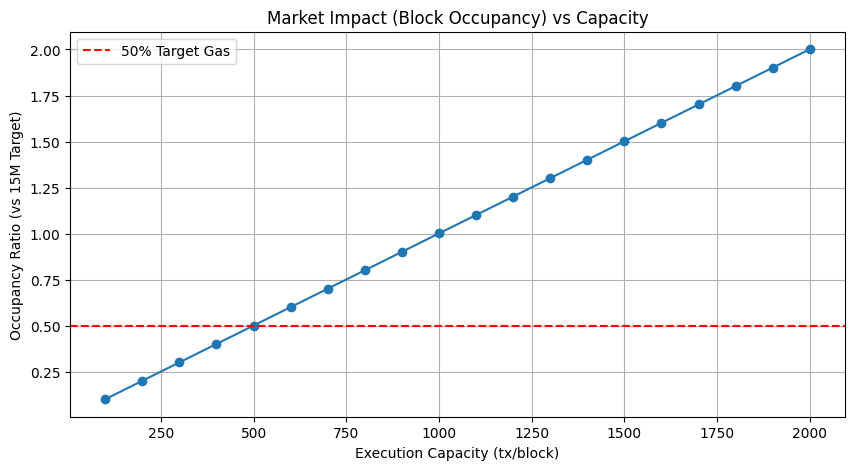

In [8]:
def tx_to_gas(n_tx):
    return 21000 + n_tx * 15000

test_caps = np.arange(100, 2001, 100)
gas_usages = [tx_to_gas(c) for c in test_caps]
occupancy = [g / 15000000 for g in gas_usages] # So với Target 15M

plt.figure(figsize=(10, 5))
plt.plot(test_caps, occupancy, marker='o')
plt.axhline(0.5, color='r', linestyle='--', label='50% Target Gas')
plt.title('Market Impact (Block Occupancy) vs Capacity')
plt.xlabel('Execution Capacity (tx/block)')
plt.ylabel('Occupancy Ratio (vs 15M Target)')
plt.legend()
plt.grid(True)
plt.show()
